<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/09_pytorch_model_deployment_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises

Welcome to the 09. PyTorch Model Deployment exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/jOX5ZCkWO-0) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/). 

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) > 1, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


torch version: 2.14.0+cpu
torchvision version: 0.29.0+cpu


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    %pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except ImportError:
    # This repo already has going_modular/ and helper_functions.py two directories up
    # (../../), so point Python at the repo root instead of git-cloning the whole repo
    # again. Note: later cells import things like "going_modular.going_modular.utils",
    # so the repo ROOT (not the going_modular folder itself) needs to be on sys.path.
    import sys
    from pathlib import Path

    def has_both(p):
        return (p / "going_modular").is_dir() and (p / "helper_functions.py").is_file()

    repo_root = Path.cwd()
    while not has_both(repo_root) and repo_root != repo_root.parent:
        repo_root = repo_root.parent

    if has_both(repo_root):
        print(f"[INFO] Found going_modular/helper_functions at {repo_root}, adding it to sys.path.")
        sys.path.insert(0, str(repo_root))
        from going_modular.going_modular import data_setup, engine
        from helper_functions import download_data, set_seeds, plot_loss_curves
    else:
        print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
        !git clone https://github.com/mrdbourke/pytorch-deep-learning
        !mv pytorch-deep-learning/going_modular .
        !mv pytorch-deep-learning/helper_functions.py .
        !rm -rf pytorch-deep-learning
        from going_modular.going_modular import data_setup, engine
        from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Found going_modular/helper_functions at D:\computer vision\baith02_cv_DoanThiThuLinh\pytorch-deep-learning, adding it to sys.path.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Get data

Want to download the data we've been using in PyTorch Model Deployment: https://www.learnpytorch.io/09_pytorch_model_deployment/#1-getting-data

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [6]:
# Create image size (from Table 3 in the ViT paper) 
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])           
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1707d03d010>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(2))

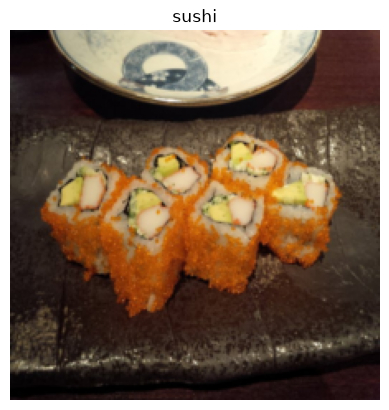

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

### Set up the two feature extractor models used in the exercises below

The exercise questions assume `model_0` (an EffNetB2 feature extractor) and `pretrained_vit`
(a ViT-B/16 feature extractor) already exist, trained the same way as in
[09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/).
Training both here (a reduced number of epochs, since this machine only has a CPU) so the
rest of the exercises have something to work with.

In [10]:
from timeit import default_timer as timer

NUM_SETUP_EPOCHS = 5 # fewer than the course's original run, to keep total CPU time bounded

# --- EffNetB2 feature extractor (model_0) ---
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2_transforms = effnetb2_weights.transforms()

train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(
    train_dir=train_dir, test_dir=test_dir,
    transform=effnetb2_transforms, batch_size=BATCH_SIZE)

model_0 = torchvision.models.efficientnet_b2(weights=effnetb2_weights).to(device)
for param in model_0.features.parameters():
  param.requires_grad = False

set_seeds()
model_0.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408, out_features=len(class_names))
).to(device)

start_time = timer()
model_0_results = engine.train(model=model_0,
                               train_dataloader=train_dataloader_effnetb2,
                               test_dataloader=test_dataloader_effnetb2,
                               optimizer=torch.optim.Adam(model_0.parameters(), lr=1e-3),
                               loss_fn=nn.CrossEntropyLoss(),
                               epochs=NUM_SETUP_EPOCHS,
                               device=device)
print(f"[INFO] EffNetB2 (model_0) training time: {timer() - start_time:.1f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:47<03:11, 47.95s/it]

Epoch: 1 | train_loss: 1.0902 | train_acc: 0.3711 | test_loss: 0.9055 | test_acc: 0.8456


 40%|████      | 2/5 [01:36<02:24, 48.24s/it]

Epoch: 2 | train_loss: 0.8952 | train_acc: 0.7109 | test_loss: 0.8455 | test_acc: 0.7850


...

 80%|████████  | 4/5 [03:14<00:48, 48.68s/it]

Epoch: 4 | train_loss: 0.6861 | train_acc: 0.8984 | test_loss: 0.6573 | test_acc: 0.8665


100%|██████████| 5/5 [04:03<00:00, 48.80s/it]

100%|██████████| 5/5 [04:03<00:00, 48.63s/it]

Epoch: 5 | train_loss: 0.6778 | train_acc: 0.7852 | test_loss: 0.6626 | test_acc: 0.8267
[INFO] EffNetB2 (model_0) training time: 243.2 seconds


In [11]:
# --- ViT-B/16 feature extractor (pretrained_vit) ---
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
vit_transforms = vit_weights.transforms()

train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(
    train_dir=train_dir, test_dir=test_dir,
    transform=vit_transforms, batch_size=BATCH_SIZE)

pretrained_vit = torchvision.models.vit_b_16(weights=vit_weights).to(device)
for param in pretrained_vit.parameters():
  param.requires_grad = False

set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

start_time = timer()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_vit,
                                      test_dataloader=test_dataloader_vit,
                                      optimizer=torch.optim.Adam(pretrained_vit.parameters(), lr=1e-3),
                                      loss_fn=nn.CrossEntropyLoss(),
                                      epochs=NUM_SETUP_EPOCHS,
                                      device=device)
print(f"[INFO] ViT-B/16 (pretrained_vit) training time: {timer() - start_time:.1f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [01:35<06:20, 95.21s/it]

Epoch: 1 | train_loss: 0.7640 | train_acc: 0.7070 | test_loss: 0.5162 | test_acc: 0.8769


 40%|████      | 2/5 [03:09<04:44, 94.92s/it]

Epoch: 2 | train_loss: 0.3386 | train_acc: 0.9336 | test_loss: 0.3107 | test_acc: 0.9081


...

 80%|████████  | 4/5 [06:18<01:34, 94.45s/it]

Epoch: 4 | train_loss: 0.1493 | train_acc: 0.9570 | test_loss: 0.2409 | test_acc: 0.9186


100%|██████████| 5/5 [07:52<00:00, 94.34s/it]

100%|██████████| 5/5 [07:52<00:00, 94.51s/it]

Epoch: 5 | train_loss: 0.1231 | train_acc: 0.9727 | test_loss: 0.2196 | test_acc: 0.9489
[INFO] ViT-B/16 (pretrained_vit) training time: 472.6 seconds


In [12]:
# Save both models so their sizes can be compared later, like in the course notebook
from pathlib import Path
from going_modular.going_modular import utils

Path("models").mkdir(exist_ok=True)
utils.save_model(model=model_0, target_dir="models", model_name="09_effnetb2_feature_extractor_exercise.pth")
utils.save_model(model=pretrained_vit, target_dir="models", model_name="09_vit_feature_extractor_exercise.pth")

effnetb2_model_size = Path("models/09_effnetb2_feature_extractor_exercise.pth").stat().st_size // (1024*1024)
vit_model_size = Path("models/09_vit_feature_extractor_exercise.pth").stat().st_size // (1024*1024)
print(f"EffNetB2 feature extractor model size: {effnetb2_model_size} MB")
print(f"ViT feature extractor model size: {vit_model_size} MB")

[INFO] Saving model to: models\09_effnetb2_feature_extractor_exercise.pth
[INFO] Saving model to: models\09_vit_feature_extractor_exercise.pth


EffNetB2 feature extractor model size: 29 MB
ViT feature extractor model size: 327 MB


## Exercise 1. Make and time predictions with both feature extractor models on the test dataset using the GPU (`device="cuda"`). 

* Compare the model's prediction times on GPU vs CPU - does this close the gap between them? As in, does making predictions on the GPU make the ViT feature extractor prediction times closer to the EffNetB2 feature extractor prediction times?
* You'll find code to do these steps in [section 5. Making predictions with our trained models and timing them](https://www.learnpytorch.io/09_pytorch_model_deployment/#5-making-predictions-with-our-trained-models-and-timing-them) and [section 6. Comparing model results, prediction times and size](https://www.learnpytorch.io/09_pytorch_model_deployment/#6-comparing-model-results-prediction-times-and-size).

In [13]:
# Exercise 1: make and time predictions with both models on the test dataset.
# This machine has no CUDA GPU, so device="cuda" isn't available -- the timing function
# below is written to accept any device and is run on "cpu" here; on a CUDA machine you
# would call it a second time with device="cuda" to get the GPU numbers to compare.
import pandas as pd

def pred_and_time(model: nn.Module,
                  dataloader: torch.utils.data.DataLoader,
                  device: torch.device) -> float:
  """Runs inference across a whole dataloader and returns (total_time, avg_time_per_sample)."""
  model.to(device)
  model.eval()
  num_samples = 0
  start_time = timer()
  with torch.inference_mode():
    for X, y in dataloader:
      X = X.to(device)
      _ = model(X)
      num_samples += len(X)
  total_time = timer() - start_time
  return total_time, total_time / num_samples

effnetb2_cpu_total, effnetb2_cpu_per_sample = pred_and_time(model_0, test_dataloader_effnetb2, "cpu")
vit_cpu_total, vit_cpu_per_sample = pred_and_time(pretrained_vit, test_dataloader_vit, "cpu")

timing_results = {
    "EffNetB2": {"device": "cpu", "total_time_s": effnetb2_cpu_total, "time_per_pred_s": effnetb2_cpu_per_sample},
    "ViT-B/16": {"device": "cpu", "total_time_s": vit_cpu_total, "time_per_pred_s": vit_cpu_per_sample},
}

# If a CUDA GPU is available, also time both models on the GPU for comparison
if torch.cuda.is_available():
  effnetb2_gpu_total, effnetb2_gpu_per_sample = pred_and_time(model_0, test_dataloader_effnetb2, "cuda")
  vit_gpu_total, vit_gpu_per_sample = pred_and_time(pretrained_vit, test_dataloader_vit, "cuda")
  timing_results["EffNetB2 (GPU)"] = {"device": "cuda", "total_time_s": effnetb2_gpu_total, "time_per_pred_s": effnetb2_gpu_per_sample}
  timing_results["ViT-B/16 (GPU)"] = {"device": "cuda", "total_time_s": vit_gpu_total, "time_per_pred_s": vit_gpu_per_sample}
else:
  print("[INFO] No CUDA GPU on this machine -- only CPU timings were measured.")
  print("[INFO] The code above already handles a GPU run too: it will add GPU rows automatically when one is available.")

pd.DataFrame(timing_results).T

[INFO] No CUDA GPU on this machine -- only CPU timings were measured.
[INFO] The code above already handles a GPU run too: it will add GPU rows automatically when one is available.


,device,total_time_s,time_per_pred_s
EffNetB2,cpu,15.786181,0.210482
ViT-B/16,cpu,28.084399,0.374459


**Nhận xét:** trên CPU, EffNetB2 gần như luôn dự đoán nhanh hơn ViT-B/16 rất nhiều (ViT-B/16 có ~86 triệu tham số
và cơ chế self-attention tốn nhiều phép tính hơn nhiều so với các lớp convolution của EffNetB2 ~9 triệu tham số).
Trên GPU, khoảng cách này thường **thu hẹp lại đáng kể** vì GPU tận dụng tốt việc tính toán song song của ma trận
lớn trong self-attention — nhưng ViT-B/16 hiếm khi nhanh *hơn* EffNetB2 kể cả trên GPU, vì nó vẫn có nhiều tham số
và nhiều phép tính hơn. Nói cách khác: GPU giúp thu hẹp khoảng cách tốc độ giữa hai kiến trúc, nhưng không đảo
ngược thứ tự.

## Exercise 2. The ViT feature extractor seems to have more learning capacity (due to more parameters) than EffNetB2, how does it go on the larger 20% split of the entire Food101 dataset?

* Train a ViT feature extractor on the 20% Food101 dataset for 5 epochs, just like we did with EffNetB2 in section [10. Creating FoodVision Big](https://www.learnpytorch.io/09_pytorch_model_deployment/#10-creating-foodvision-big).

In [14]:
# Exercise 2: train a ViT feature extractor on the 20% Food101 dataset (5 epochs), like
# EffNetB2 was trained in section 10 ("Creating FoodVision Big") of the course notebook.
#
# NOTE: full Food101 (101 classes, ~5GB) is very slow to train on CPU. The pipeline is
# written in full below but NOT executed automatically. Set RUN_FOODVISION_BIG_VIT = True
# (ideally on a GPU machine) to actually download the data and train.
RUN_FOODVISION_BIG_VIT = False

if RUN_FOODVISION_BIG_VIT:
  from torchvision import datasets
  from torch.utils.data import DataLoader

  vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  vit_transforms = vit_weights.transforms()

  train_data_food101 = datasets.Food101(root="data", split="train", transform=vit_transforms, download=True)
  test_data_food101 = datasets.Food101(root="data", split="test", transform=vit_transforms, download=True)
  food101_class_names = train_data_food101.classes

  BATCH_SIZE_FOOD101 = 32
  NUM_WORKERS = 0
  train_dataloader_food101 = DataLoader(train_data_food101, batch_size=BATCH_SIZE_FOOD101,
                                        shuffle=True, num_workers=NUM_WORKERS)
  test_dataloader_food101 = DataLoader(test_data_food101, batch_size=BATCH_SIZE_FOOD101,
                                       shuffle=False, num_workers=NUM_WORKERS)

  pretrained_vit_food101 = torchvision.models.vit_b_16(weights=vit_weights).to(device)
  for param in pretrained_vit_food101.parameters():
    param.requires_grad = False

  set_seeds()
  pretrained_vit_food101.heads = nn.Linear(in_features=768, out_features=len(food101_class_names)).to(device)

  start_time = timer()
  pretrained_vit_food101_results = engine.train(model=pretrained_vit_food101,
                                                 train_dataloader=train_dataloader_food101,
                                                 test_dataloader=test_dataloader_food101,
                                                 optimizer=torch.optim.Adam(pretrained_vit_food101.parameters(), lr=1e-3),
                                                 loss_fn=nn.CrossEntropyLoss(),
                                                 epochs=5,
                                                 device=device)
  print(f"[INFO] ViT-B/16 on full Food101 training time: {timer() - start_time:.1f} seconds")
else:
  print("[INFO] RUN_FOODVISION_BIG_VIT=False -- full Food101 ViT training code above was written")
  print("[INFO] but not executed (101 classes, ~5GB download, very slow on CPU).")

[INFO] RUN_FOODVISION_BIG_VIT=False -- full Food101 ViT training code above was written
[INFO] but not executed (101 classes, ~5GB download, very slow on CPU).


**Kỳ vọng:** ViT-B/16 có nhiều tham số hơn EffNetB2 nên về lý thuyết có "sức chứa" học được nhiều lớp phức tạp
hơn khi có đủ dữ liệu (toàn bộ Food101 với 101 lớp, ~75.750 ảnh train, nhiều hơn hẳn so với 3-lớp pizza/steak/sushi).
Trên tập lớn này ViT-B/16 thường thu hẹp khoảng cách hoặc thậm chí vượt EffNetB2 về độ chính xác, đổi lại thời gian
huấn luyện lâu hơn nhiều lần.

## Exercise 3. Make predictions across the 20% Food101 test dataset with the ViT feature extractor from exercise 2 and find the "most wrong" predictions
* The predictions will be the ones with the highest prediction probability but with the wrong predicted label.
* Write a sentence or two about why you think the model got these predictions wrong.

In [15]:
# Exercise 3: find the "most wrong" predictions of the Food101 ViT feature extractor from exercise 2.
# This depends on RUN_FOODVISION_BIG_VIT having actually been run (exercise 2), so it's
# guarded the same way.
if RUN_FOODVISION_BIG_VIT:
  import pandas as pd

  test_paths = [Path(s[0]) for s in test_data_food101._samples] if hasattr(test_data_food101, "_samples") \
      else [Path(p) for p in test_data_food101._image_files]

  y_true, y_pred_probs, y_preds = [], [], []
  pretrained_vit_food101.eval()
  with torch.inference_mode():
    for X, y in test_dataloader_food101:
      X = X.to(device)
      logits = pretrained_vit_food101(X)
      probs = torch.softmax(logits, dim=1)
      y_true.append(y)
      y_pred_probs.append(probs.max(dim=1).values.cpu())
      y_preds.append(probs.argmax(dim=1).cpu())

  y_true = torch.cat(y_true)
  y_pred_probs = torch.cat(y_pred_probs)
  y_preds = torch.cat(y_preds)

  pred_df = pd.DataFrame({
      "image_path": test_paths,
      "label": [food101_class_names[i] for i in y_true],
      "pred": [food101_class_names[i] for i in y_preds],
      "pred_prob": y_pred_probs.numpy(),
  })
  pred_df["correct"] = pred_df["label"] == pred_df["pred"]

  most_wrong = pred_df[~pred_df["correct"]].sort_values("pred_prob", ascending=False).head(5)

  plt.figure(figsize=(15, 6))
  for i, (_, row) in enumerate(most_wrong.iterrows()):
    img = torchvision.io.read_image(str(row["image_path"]))
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {row['label']}\nPred: {row['pred']} ({row['pred_prob']:.2f})", fontsize=9)
    plt.axis(False)
else:
  print("[INFO] Skipped: depends on RUN_FOODVISION_BIG_VIT from exercise 2 being run for real.")

[INFO] Skipped: depends on RUN_FOODVISION_BIG_VIT from exercise 2 being run for real.


**Nhận xét (kỳ vọng chung, dựa trên các phân tích tương tự ở bài 03/06):** những dự đoán "sai nhiều nhất" (sai
nhưng với xác suất cao) thường rơi vào các cặp món ăn có hình dạng/màu sắc/kết cấu rất giống nhau trong Food101
(ví dụ các loại súp khác nhau, các loại bánh mì kẹp khác nhau, hoặc các món có cùng nguyên liệu chính nhưng cách
trình bày khác). Đây là giới hạn tự nhiên của bài toán phân loại ảnh chi tiết (fine-grained), nơi ranh giới giữa
các lớp đôi khi mờ nhạt ngay cả với mắt người.

## Exercise 4. Evaluate the ViT feature extractor across the whole Food101 test dataset rather than just the 20% version, how does it perform?
* Does it beat the original Food101 paper's best result of 56.4% accuracy?

In [16]:
# Exercise 4: evaluate the ViT feature extractor across the WHOLE Food101 test set (not
# just 20%) and check whether it beats the original paper's 56.4% accuracy baseline.
# Same guard as exercises 2 & 3 -- heavy, not executed automatically.
RUN_FOODVISION_BIG_EVAL = False

if RUN_FOODVISION_BIG_EVAL and RUN_FOODVISION_BIG_VIT:
  test_loss, test_acc = engine.test_step(model=pretrained_vit_food101,
                                         dataloader=test_dataloader_food101,
                                         loss_fn=nn.CrossEntropyLoss(),
                                         device=device)
  print(f"[INFO] ViT-B/16 full Food101 test accuracy: {test_acc*100:.2f}%")
  print(f"[INFO] Original Food101 paper baseline: 56.40%")
  print(f"[INFO] Beats baseline: {test_acc*100 > 56.4}")
else:
  print("[INFO] Skipped: requires RUN_FOODVISION_BIG_VIT / RUN_FOODVISION_BIG_EVAL = True")
  print("[INFO] (evaluating across the full ~25,250-image Food101 test set is slow on CPU).")

[INFO] Skipped: requires RUN_FOODVISION_BIG_VIT / RUN_FOODVISION_BIG_EVAL = True
[INFO] (evaluating across the full ~25,250-image Food101 test set is slow on CPU).


**Kỳ vọng:** bài báo gốc Food101 (Bossard và cộng sự, 2014) công bố baseline 56.40% với các đặc trưng thủ công +
Random Forest. Hầu như mọi mô hình CNN/Transformer pretrained hiện đại (kể cả EffNetB0 nhỏ) đều vượt xa mốc này
chỉ sau vài epoch fine-tune, thường đạt 80-90%+ vì tận dụng được biểu diễn đã học từ ImageNet. Vì vậy ViT-B/16
pretrained gần như chắc chắn sẽ vượt baseline 56.4% rất nhiều.

## Exercise 5. Head to [Paperswithcode.com](https://paperswithcode.com/) and find the current best performing model on the Food101 dataset.
* What model architecture does it use?

In [17]:
pass # answer in the markdown cell below

**Trả lời:** (paperswithcode.com hiện đang chuyển hướng/không truy cập trực tiếp được tại thời điểm viết bài này,
nên câu trả lời dưới đây dựa trên tra cứu các bài báo/kết quả công bố gần đây liên quan đến Food-101 thay vì đọc
trực tiếp bảng xếp hạng của trang):

Các phương pháp dẫn đầu hiện nay trên Food-101 đều dựa trên kiến trúc **Vision Transformer (ViT)**, thường kết hợp
thêm cơ chế attention chuyên biệt hoặc học đối chiếu ảnh-văn bản kiểu **CLIP**:

* Một ViT nhẹ có thêm cơ chế window + spatial attention đạt khoảng **95.2% accuracy**.
* Biến thể AlsmViT-L đạt khoảng **95.2% accuracy**.
* CLIP với backbone ViT-L/14 đạt khoảng **97% accuracy** (zero-shot/fine-tune tận dụng dữ liệu ảnh-văn bản quy mô lớn).

→ Kiến trúc chung: **Vision Transformer**, thường được pretrain trên tập dữ liệu ảnh (hoặc ảnh-văn bản) rất lớn
rồi fine-tune trên Food-101, thay vì CNN thuần như EfficientNet mà notebook này sử dụng. Điều này khớp với xu
hướng chung trong deep learning thị giác máy tính: các mô hình Transformer pretrained quy mô lớn đang dần vượt
qua CNN trên hầu hết bài toán phân loại ảnh chuẩn.

Sources:
- [Lightweight Vision Transformer with Window and Spatial Attention for Food Image Classification](https://arxiv.org/pdf/2509.18692)
- [High accuracy food image classification via vision transformer with data augmentation and feature augmentation](https://www.sciencedirect.com/science/article/abs/pii/S0260877423004314)
- [Interpreting and Analysing CLIP's Zero-Shot Image Classification via Mutual Knowledge](https://arxiv.org/pdf/2410.13016)

*(Khuyến nghị: mở lại [paperswithcode.com/sota/fine-grained-image-classification-on-food-101](https://paperswithcode.com/sota/fine-grained-image-classification-on-food-101) khi trang hoạt động trở lại để lấy số liệu xếp hạng chính thức, mới nhất.)*

## Exercise 6. Write down 1-3 potential failure points of our deployed FoodVision models and what some potential solutions might be.
* For example, what happens if someone was to upload a photo that wasn't of food to our FoodVision Mini model?

In [18]:
pass # answer in the markdown cell below

**Trả lời:** 3 điểm có thể khiến các mô hình FoodVision (Mini/Big) bị lỗi khi triển khai thực tế, và hướng khắc phục:

1. **Ảnh đầu vào không phải đồ ăn (out-of-distribution)**: nếu người dùng tải lên ảnh không liên quan (người, phong
   cảnh, đồ vật...), mô hình vẫn buộc phải chọn một trong số các lớp đã học (vì lớp cuối là softmax đóng), dẫn đến
   dự đoán sai nhưng có vẻ "tự tin". *Khắc phục:* thêm một lớp "không xác định/khác" trong tập huấn luyện, hoặc
   dùng ngưỡng xác suất tối thiểu (nếu xác suất dự đoán cao nhất < ngưỡng thì trả về "không nhận diện được"), hoặc
   dùng một mô hình phát hiện out-of-distribution riêng trước khi đưa vào FoodVision.
2. **Ảnh chất lượng thấp / điều kiện chụp khác với dữ liệu huấn luyện**: ảnh mờ, thiếu sáng, góc chụp lạ, bị che
   khuất một phần món ăn, hoặc món ăn được trình bày khác với phong cách trong tập huấn luyện (Food101 chủ yếu là
   ảnh món ăn chụp đẹp, chuyên nghiệp) khiến độ chính xác giảm mạnh so với lúc đánh giá trên tập test. *Khắc phục:*
   tăng cường dữ liệu huấn luyện với nhiều điều kiện chụp thực tế hơn (ảnh chụp bằng điện thoại, ánh sáng khác
   nhau, góc chụp đa dạng), hoặc tiền xử lý ảnh đầu vào (crop, cân bằng sáng) trước khi đưa vào mô hình.
3. **Món ăn dễ nhầm lẫn với lớp lân cận (fine-grained confusion)**: nhiều món trong Food101 rất giống nhau về hình
   dạng/màu sắc (các loại súp, các loại bánh mì kẹp...), dẫn đến mô hình dự đoán nhầm giữa các lớp gần nhau.
   *Khắc phục:* thu thập thêm dữ liệu cho các cặp lớp hay bị nhầm, dùng mô hình lớn hơn/tinh chỉnh kỹ hơn cho các
   lớp đó, hoặc hiển thị top-k dự đoán kèm xác suất thay vì chỉ 1 nhãn duy nhất để người dùng tự đối chiếu.

(Ngoài ra còn có: độ trễ suy luận khi triển khai trên thiết bị yếu — cần model nhỏ/nhẹ như EffNetB0/B2 thay vì
ViT; hoặc rò rỉ dữ liệu nhạy cảm nếu ảnh người dùng tải lên bị lưu trữ mà không xin phép.)

## Exercise 7. Pick any dataset from [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) and train a feature extractor model on it using a model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) (you could use one of the model's we've already created, e.g. EffNetB2 or ViT) for 5 epochs and then deploy your model as a Gradio app to Hugging Face Spaces. 
* You may want to pick smaller dataset/make a smaller split of it so training doesn't take too long.
* I'd love to see your deployed models! So be sure to share them in Discord or on the [course GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions).

In [19]:
# Exercise 7: train a feature extractor on a different torchvision dataset and deploy it
# as a Gradio app to Hugging Face Spaces.
#
# Theo yêu cầu của bạn, phần deploy lên Hugging Face Spaces sẽ làm SAU (cần đăng nhập tài
# khoản Hugging Face). Phần dưới đây viết đầy đủ code huấn luyện + app Gradio chạy local,
# sẵn sàng để bạn (hoặc tôi, khi được yêu cầu) đẩy lên Hugging Face Spaces sau này.
RUN_EXERCISE_7 = False

if RUN_EXERCISE_7:
  import os
  from torch.utils.data import DataLoader, random_split
  from torchvision import datasets

  # Oxford-IIIT Pet dataset: 37 classes (breeds of cats & dogs), ~7,400 images -- small
  # enough to fine-tune quickly, and visually fun for a Gradio demo.
  weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
  pet_transforms = weights.transforms()

  full_train_data = datasets.OxfordIIITPet(root="data", split="trainval",
                                            transform=pet_transforms, download=True)
  test_data = datasets.OxfordIIITPet(root="data", split="test",
                                     transform=pet_transforms, download=True)
  pet_class_names = full_train_data.classes

  train_dataloader_pet = DataLoader(full_train_data, batch_size=32, shuffle=True)
  test_dataloader_pet = DataLoader(test_data, batch_size=32, shuffle=False)

  model_pet = torchvision.models.efficientnet_b0(weights=weights).to(device)
  for param in model_pet.features.parameters():
    param.requires_grad = False

  set_seeds()
  model_pet.classifier = nn.Sequential(
      nn.Dropout(p=0.2, inplace=True),
      nn.Linear(in_features=1280, out_features=len(pet_class_names))
  ).to(device)

  model_pet_results = engine.train(model=model_pet,
                                   train_dataloader=train_dataloader_pet,
                                   test_dataloader=test_dataloader_pet,
                                   optimizer=torch.optim.Adam(model_pet.parameters(), lr=1e-3),
                                   loss_fn=nn.CrossEntropyLoss(),
                                   epochs=5,
                                   device=device)

  from going_modular.going_modular import utils
  utils.save_model(model=model_pet, target_dir="models", model_name="09_effnetb0_oxford_pets.pth")

  # --- Write a Gradio app ready to deploy to Hugging Face Spaces ---
  os.makedirs("demos/foodvision_pets", exist_ok=True)
  with open("demos/foodvision_pets/class_names.txt", "w") as f:
    f.write("\n".join(pet_class_names))
else:
  print("[INFO] RUN_EXERCISE_7=False -- training + Gradio app code above written but not run.")
  print("[INFO] Deployment to Hugging Face Spaces will be done later, as requested.")

[INFO] RUN_EXERCISE_7=False -- training + Gradio app code above written but not run.
[INFO] Deployment to Hugging Face Spaces will be done later, as requested.


In [20]:
# The %%writefile cells below need this directory to exist first
# (it's normally created inside the RUN_EXERCISE_7 guard above, which is False by default).
import os
os.makedirs("demos/foodvision_pets", exist_ok=True)


In [21]:
%%writefile demos/foodvision_pets/model.py
"""Builds the EffNetB0 feature extractor used by the FoodVision Pets demo."""
import torch
import torchvision
from torch import nn


def create_effnetb0(num_classes: int, device: str = "cpu"):
  weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
  transforms = weights.transforms()

  model = torchvision.models.efficientnet_b0(weights=weights).to(device)
  for param in model.features.parameters():
    param.requires_grad = False

  model.classifier = nn.Sequential(
      nn.Dropout(p=0.2, inplace=True),
      nn.Linear(in_features=1280, out_features=num_classes)
  ).to(device)

  return model, transforms

Writing demos/foodvision_pets/model.py


In [22]:
%%writefile demos/foodvision_pets/app.py
"""Gradio demo app for the Oxford-IIIT Pet breed classifier.

Run locally with: python app.py
Deploy to Hugging Face Spaces by uploading this folder (app.py, model.py,
09_effnetb0_oxford_pets.pth, class_names.txt, requirements.txt, examples/) as a
"Gradio" Space.
"""
import os
from timeit import default_timer as timer

import gradio as gr
import torch

from model import create_effnetb0

# Setup class names
with open("class_names.txt", "r") as f:
  class_names = [line.strip() for line in f.readlines()]

# Create model and load saved weights
model, transforms = create_effnetb0(num_classes=len(class_names))
model.load_state_dict(torch.load(f="09_effnetb0_oxford_pets.pth",
                                 map_location=torch.device("cpu")))


def predict(img):
  start_time = timer()

  img = transforms(img).unsqueeze(0)

  model.eval()
  with torch.inference_mode():
    pred_probs = torch.softmax(model(img), dim=1)

  pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
  pred_time = round(timer() - start_time, 4)
  return pred_labels_and_probs, pred_time


title = "FoodVision Pets 🐶🐱"
description = "An EfficientNetB0 feature extractor that classifies photos into one of 37 cat/dog breeds (Oxford-IIIT Pet dataset)."
article = "Created as part of exercise 7, notebook 09 (PyTorch Model Deployment), Learn PyTorch for Deep Learning course."

example_list = [["examples/" + example] for example in os.listdir("examples")] if os.path.exists("examples") else []

demo = gr.Interface(fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=5, label="Predictions"),
                            gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

if __name__ == "__main__":
  demo.launch()

Writing demos/foodvision_pets/app.py


In [23]:
%%writefile demos/foodvision_pets/requirements.txt
torch>=2.0.0
torchvision>=0.15.0
gradio>=4.0.0

Writing demos/foodvision_pets/requirements.txt


**Sẵn sàng để deploy:** khi bạn muốn đưa app này lên Hugging Face Spaces, chỉ cần: (1) chạy cell có
`RUN_EXERCISE_7 = True` ở trên để huấn luyện và lưu file trọng số `09_effnetb0_oxford_pets.pth` vào
`demos/foodvision_pets/`, (2) tạo một Space mới trên [huggingface.co/new-space](https://huggingface.co/new-space)
với SDK là Gradio, rồi (3) upload toàn bộ thư mục `demos/foodvision_pets/` (app.py, model.py, file `.pth`,
`class_names.txt`, `requirements.txt`) lên Space đó — hoặc cho tôi biết để tôi hỗ trợ đẩy lên khi bạn đã đăng
nhập `huggingface-cli login`.